# Paper 1: Machine Learning–Based Urban Flood Risk Assessment with Cross-City Validation: Chennai and Bengaluru

## Step 1-4: Data Processing Pipeline

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import geopandas as gpd

from sklearn.model_selection import train_test_split,TimeSeriesSplit
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import *

import warnings
warnings.filterwarnings('ignore')

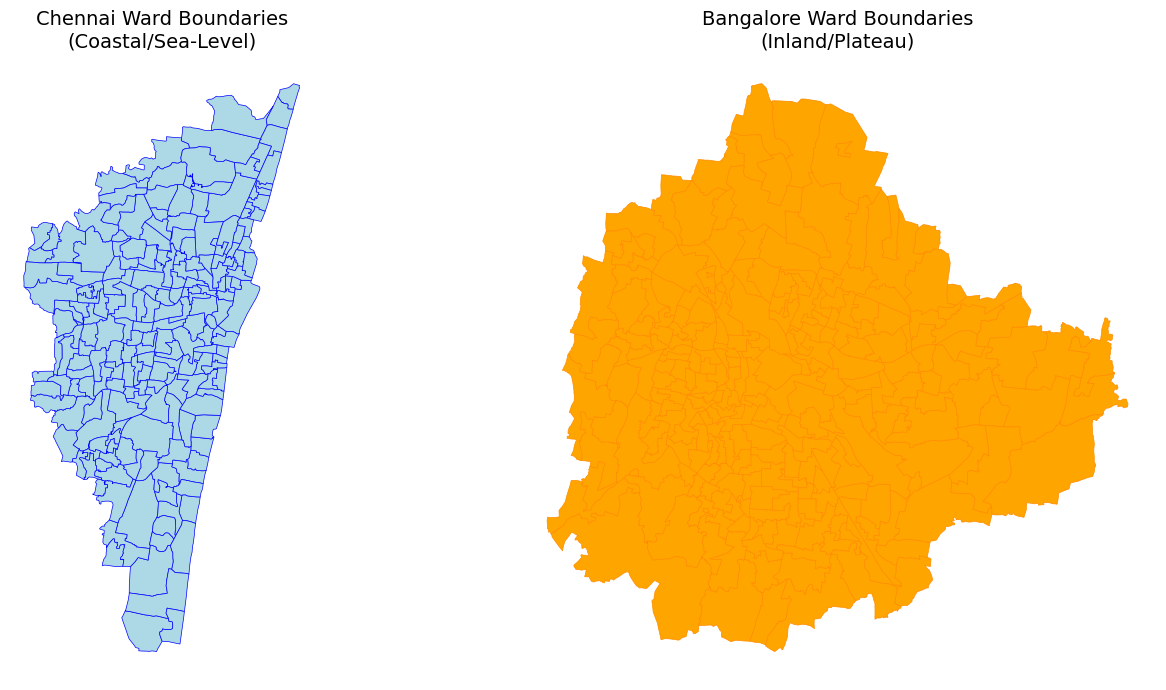

In [24]:
# 1. Load the GeoJSON files
# Note: Update the paths if these are inside a subfolder (e.g., 'GeoData/Wards.geojson')
chennai_gdf = gpd.read_file('geojson/Chennai.geojson')
bangalore_gdf = gpd.read_file('geojson/Bangalore.geojson')

# 2. Ensure both use the same Coordinate Reference System (GPS standard)
chennai_gdf = chennai_gdf.to_crs("EPSG:4326")
bangalore_gdf = bangalore_gdf.to_crs("EPSG:4326")

# 3. Plot them side-by-side to verify the study areas
fig, axes = plt.subplots(1, 2, figsize=(15, 7))

# Plot Chennai Wards (Coastal Plain)
chennai_gdf.plot(ax=axes[0], color='lightblue', edgecolor='blue', linewidth=0.5)
axes[0].set_title("Chennai Ward Boundaries\n(Coastal/Sea-Level)", fontsize=14)
axes[0].axis('off')

# Plot Bangalore Wards (Urban Plateau)
bangalore_gdf.plot(ax=axes[1], color='orange', edgecolor='darkorange', linewidth=0.5)
axes[1].set_title("Bangalore Ward Boundaries\n(Inland/Plateau)", fontsize=14)
axes[1].axis('off')

plt.tight_layout()
plt.show()

In [25]:
def load_and_clean_data(filepath, boundary_gdf, location_col_name):
    df = pd.read_csv(filepath)
    df = df.rename(columns={'valid_time': 'Date', 'tp': 'Rainfall'})
    df['Rainfall'] = df['Rainfall'].fillna(0) * 1000
    df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y %H:%M', errors='coerce')
    df = df.dropna(subset=['Date', 'latitude', 'longitude'])
    
    weather_gdf = gpd.GeoDataFrame(
        df, 
        geometry=gpd.points_from_xy(df['longitude'], df['latitude']),
        crs="EPSG:4326"
    )
    
    boundary_gdf = boundary_gdf.to_crs("EPSG:4326")
    
    joined_gdf = gpd.sjoin(weather_gdf, boundary_gdf, how="inner", predicate="within")
    
    df_spatial = joined_gdf.groupby(['Date', location_col_name])['Rainfall'].agg([
    'sum',
    'mean',
    'max',
    'std',
]).reset_index()

    df_spatial.columns = [
    'Date',
    location_col_name,
    'Rain_sum',
    'Rain_mean',
    'Rain_max',
    'Rain_std',
]

    # Handle NaN std (when only one point exists)
    df_spatial['Rain_std'] = df_spatial['Rain_std'].fillna(0)

    # Heavy rainfall hotspot indicator
    df_spatial['Heavy_Rain_Flag'] = (df_spatial['Rain_max'] >= 115).astype(int)

    df_spatial.set_index('Date', inplace=True)
    
    df_daily = pd.DataFrame()

    df_daily['Daily_Total_Rain'] = df_spatial.groupby(location_col_name)['Rain_sum'] \
    .resample('D').sum().reset_index(level=0, drop=True)

    df_daily['Avg_Rainfall'] = df_spatial.groupby(location_col_name)['Rain_mean'] \
    .resample('D').mean().reset_index(level=0, drop=True)

    df_daily['Max_Rainfall'] = df_spatial.groupby(location_col_name)['Rain_max'] \
    .resample('D').max().reset_index(level=0, drop=True)

    df_daily['Rainfall_Variability'] = df_spatial.groupby(location_col_name)['Rain_std'] \
    .resample('D').mean().reset_index(level=0, drop=True)

    df_daily['Heavy_Rain_Occurrence'] = df_spatial.groupby(location_col_name)['Heavy_Rain_Flag'] \
    .resample('D').sum().reset_index(level=0, drop=True)

    df_daily[location_col_name] = df_spatial.groupby(location_col_name) \
    .resample('D').first().index.get_level_values(0)
    
    return df_daily.reset_index()


# ------------------------------------------------------------

def feature_engineering(df, location_col_name):
    df = df.sort_values(by=[location_col_name, 'Date'])
    df.set_index('Date', inplace=True)
    
    df['Rain_3D_Cumulative'] = df.groupby(location_col_name)['Daily_Total_Rain'] \
        .rolling(window=3).sum().reset_index(level=0, drop=True)
    
    df['Rain_7D_Cumulative'] = df.groupby(location_col_name)['Daily_Total_Rain'] \
        .rolling(window=7).sum().reset_index(level=0, drop=True)
    
    df['Rain_14D_Cumulative'] = df.groupby(location_col_name)['Daily_Total_Rain'] \
        .rolling(window=14).sum().reset_index(level=0, drop=True)
    
    # Rainy day indicator
    df['Rainy_Day'] = (df['Daily_Total_Rain'] > 1).astype(int)
    
    # Consecutive rainy days
    df['Consecutive_Rainy_Days'] = df.groupby(location_col_name)['Rainy_Day'] \
        .apply(lambda x: x * (x.groupby((x == 0).cumsum()).cumcount() + 1)) \
        .reset_index(level=0, drop=True)
    
    df['Consecutive_Rainy_Days'] = df['Consecutive_Rainy_Days'] * df['Rainy_Day']
    
    # Keep Date as a normal column for downstream filtering logic.
    return df.reset_index()


# ------------------------------------------------------------

def create_target_variable(df, city_name):
    df['City'] = city_name
    
    # -------------------------------
    # HYBRID FLOOD LOGIC (PRIMARY)
    # -------------------------------
    df['Flood_Label'] = (
        (df['Daily_Total_Rain'] > 115) |              # High daily rainfall
        (df['Rain_3D_Cumulative'] > 200) |            # 3-day accumulation
        (df['Consecutive_Rainy_Days'] >= 3)           # Persistence
    ).astype(int)
    
    # -------------------------------
    # HISTORICAL EVENTS (BOOST)
    # -------------------------------
    if city_name == 'Chennai':
        mask = ((df['Date'] >= '2015-11-01') & (df['Date'] <= '2015-12-15')) | \
               ((df['Date'] >= '2023-11-25') & (df['Date'] <= '2023-12-10'))
        df.loc[mask, 'Flood_Label'] = 1
        
    elif city_name == 'Bangalore':
        mask = (df['Date'] >= '2022-08-25') & (df['Date'] <= '2022-09-10')
        df.loc[mask, 'Flood_Label'] = 1
    
    return df


# ------------------------------------------------------------

def build_final_dataset(filepath, city_name, boundary_gdf, location_col_name):
    df_raw = load_and_clean_data(filepath, boundary_gdf, location_col_name)
    df_engineered = feature_engineering(df_raw, location_col_name)
    df_final = create_target_variable(df_engineered, city_name)
    
    return df_final

## Load Datasets
Loading data specifically adapted for the ERA5 `valid_time` and `tp` structure.

In [26]:
# 1. Load the boundary files (Ensure these paths match your folder structure)
chennai_gdf = gpd.read_file('geojson/Chennai.geojson')
bangalore_gdf = gpd.read_file('geojson/Bangalore.geojson')

# 2. Build spatiotemporal datasets using the updated pipeline
df_chennai = build_final_dataset('datasets/chennai.csv', 'Chennai', chennai_gdf, 'Ward_No')
df_val = build_final_dataset('datasets/bangalore.csv', 'Bangalore', bangalore_gdf, 'KGISWardName')

# 3. Standardize features for comparison
numeric_features = ['Daily_Total_Rain', 'Avg_Rainfall', 'Max_Rainfall', 'Rainfall_Variability', 'Heavy_Rain_Occurrence']
scaler = StandardScaler()

df_chennai[numeric_features] = scaler.fit_transform(df_chennai[numeric_features])
df_val[numeric_features] = scaler.fit_transform(df_val[numeric_features])

print('\nChennai Spatiotemporal Data Head:')
display(df_chennai.head())
print('\nBengaluru Spatiotemporal Data Head:')
display(df_val.head())


Chennai Spatiotemporal Data Head:


,Date,Daily_Total_Rain,Avg_Rainfall,Max_Rainfall,Rainfall_Variability,Heavy_Rain_Occurrence,Ward_No,Rain_3D_Cumulative,Rain_7D_Cumulative,Rain_14D_Cumulative,Rainy_Day,Consecutive_Rainy_Days,City,Flood_Label
0,2014-01-01,-0.272574,-0.272574,-0.315764,0.0,0.0,175,NaN,NaN,NaN,0,0,Chennai,0
1,2014-01-02,-0.294209,-0.294209,-0.336540,0.0,0.0,175,NaN,NaN,NaN,0,0,Chennai,0
2,2014-01-03,-0.301343,-0.301343,-0.347727,0.0,0.0,175,0.080087,NaN,NaN,0,0,Chennai,0
3,2014-01-04,-0.264025,-0.264025,-0.313739,0.0,0.0,175,0.094387,NaN,NaN,0,0,Chennai,0
4,2014-01-05,-0.305334,-0.305334,-0.354333,0.0,0.0,175,0.075777,NaN,NaN,0,0,Chennai,0



Bengaluru Spatiotemporal Data Head:


,Date,Daily_Total_Rain,Avg_Rainfall,Max_Rainfall,Rainfall_Variability,Heavy_Rain_Occurrence,KGISWardName,Rain_3D_Cumulative,Rain_7D_Cumulative,Rain_14D_Cumulative,Rainy_Day,Consecutive_Rainy_Days,City,Flood_Label
0,2014-01-01,-0.413230,-0.413230,-0.393767,0.0,0.0,Belathur,NaN,NaN,NaN,0,0,Bangalore,0
1,2014-01-02,-0.444717,-0.444717,-0.434320,0.0,0.0,Belathur,NaN,NaN,NaN,0,0,Bangalore,0
2,2014-01-03,-0.444717,-0.444717,-0.434320,0.0,0.0,Belathur,0.0343,NaN,NaN,0,0,Bangalore,0
3,2014-01-04,-0.444717,-0.444717,-0.434320,0.0,0.0,Belathur,0.0000,NaN,NaN,0,0,Bangalore,0
4,2014-01-05,-0.444717,-0.444717,-0.434320,0.0,0.0,Belathur,0.0000,NaN,NaN,0,0,Bangalore,0


## Step 5: Model Development
Training models strictly on Chennai.

In [27]:
from sklearn.model_selection import TimeSeriesSplit

# 1. Define the Spatiotemporal Feature Set
# These features capture both intensity (flash floods) and saturation (monsoon floods)
features = [
    'Daily_Total_Rain', 
    'Avg_Rainfall',
    'Max_Rainfall',
    'Rainfall_Variability',
    'Heavy_Rain_Occurrence'
]

# 2. Features and Target for Chennai (Spatiotemporal Training Set)
df_chennai = df_chennai.sort_values('Date')

# Split date (adjust if needed)
split_date = '2019-01-01'

train_df = df_chennai[df_chennai['Date'] < split_date]
test_df  = df_chennai[df_chennai['Date'] >= split_date]

# Features and labels
X_train = train_df[features]
y_train = train_df['Flood_Label']

X_test = test_df[features]
y_test = test_df['Flood_Label']

# 3. Train Logistic Regression with Balanced Weights
# 'class_weight=balanced' is critical because flood days are rare compared to dry days
log_reg = LogisticRegression(class_weight='balanced', random_state=42)
log_reg.fit(X_train, y_train)

# 4. Time-series cross validation for Random Forest
tscv = TimeSeriesSplit(n_splits=5)
cv_scores = []

for train_index, val_index in tscv.split(X_train):
    X_tr, X_val_cv = X_train.iloc[train_index], X_train.iloc[val_index]
    y_tr, y_val_cv = y_train.iloc[train_index], y_train.iloc[val_index]
    
    cv_model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
    cv_model.fit(X_tr, y_tr)
    y_pred_cv = cv_model.predict(X_val_cv)
    
    acc = accuracy_score(y_val_cv, y_pred_cv)
    cv_scores.append(acc)

# Fit final RF model on full training data for downstream validation/explainability
rf_model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rf_model.fit(X_train, y_train)

print("TimeSeries CV Scores:", cv_scores)
print("Mean Accuracy:", np.mean(cv_scores))
print("Std Deviation:", np.std(cv_scores))

print(f'Models trained on Chennai Spatiotemporal data ({len(X_train)} samples).')

TimeSeries CV Scores: [0.9703947368421053, 0.868421052631579, 0.9342105263157895, 0.930921052631579, 0.9506578947368421]
Mean Accuracy: 0.9309210526315791
Std Deviation: 0.034248460749527296
Models trained on Chennai Spatiotemporal data (1826 samples).


## Step 6: Cross-Dataset Validation
Testing generalized model performance on Bengaluru.

In [28]:
import seaborn as sns
from sklearn.metrics import confusion_matrix, precision_recall_curve, auc, accuracy_score, precision_score, recall_score, f1_score,classification_report

def evaluate_model(model, X_test, y_test, model_name="Model"):
    y_pred = model.predict(X_test)

    print("\n🔹 ML Model Performance:")
    print(classification_report(y_test, y_pred))

# -------------------------------
# BASELINE 1: Rainfall Threshold
# -------------------------------
    y_pred_baseline = (X_test['Daily_Total_Rain'] >= 115).astype(int)

    print("\n🔹 Baseline (Rainfall Threshold):")
    print(classification_report(y_test, y_pred_baseline))

# -------------------------------
# BASELINE 2: Dummy Model
# -------------------------------
    y_pred_dummy = [0] * len(y_test)

    print("\n🔹 Baseline (No Flood Prediction):")
    print(classification_report(y_test, y_pred_dummy))
    y_probs = model.predict_proba(X_test)[:, 1]
    
    # Core Metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    cm = confusion_matrix(y_test, y_pred)
    
    print(f"--- {model_name} Performance ---")
    print(f"Accuracy:  {acc:.2f}")
    print(f"Precision: {prec:.2f}")
    print(f"Recall:    {rec:.2f}")
    print(f"F1-Score:  {f1:.2f}")
    print(f"Confusion Matrix:\n{cm}\n")

    # Visualizations
    plt.figure(figsize=(12, 5))

    # 1. Confusion Matrix Heatmap
    plt.subplot(1, 2, 1)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['No Flood', 'Flood'], 
                yticklabels=['No Flood', 'Flood'])
    plt.title(f"{model_name}: Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    # 2. Precision-Recall Curve (Standard for imbalanced flood data)
    plt.subplot(1, 2, 2)
    precision, recall, _ = precision_recall_curve(y_test, y_probs)
    pr_auc = auc(recall, precision)
    plt.plot(recall, precision, color='darkgreen', lw=2, label=f'PR AUC = {pr_auc:.2f}')
    plt.title(f"{model_name}: Precision-Recall Curve")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.legend()
    plt.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()
    
    return {'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1-Score': f1, 'AUC_PR': pr_auc}


🔹 ML Model Performance:
              precision    recall  f1-score   support

           0       1.00      0.86      0.92      8154
           1       0.35      0.98      0.51       612

    accuracy                           0.87      8766
   macro avg       0.67      0.92      0.72      8766
weighted avg       0.95      0.87      0.90      8766


🔹 Baseline (Rainfall Threshold):
              precision    recall  f1-score   support

           0       0.93      1.00      0.96      8154
           1       0.00      0.00      0.00       612

    accuracy                           0.93      8766
   macro avg       0.47      0.50      0.48      8766
weighted avg       0.87      0.93      0.90      8766


🔹 Baseline (No Flood Prediction):
              precision    recall  f1-score   support

           0       0.93      1.00      0.96      8154
           1       0.00      0.00      0.00       612

    accuracy                           0.93      8766
   macro avg       0.47      0.50 

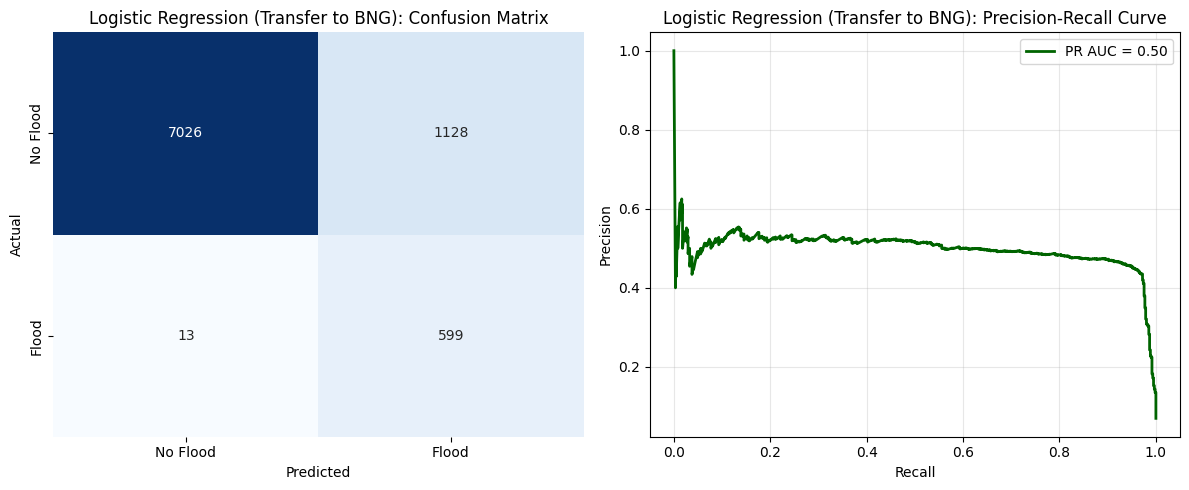


🔹 ML Model Performance:
              precision    recall  f1-score   support

           0       0.97      0.93      0.95      8154
           1       0.41      0.64      0.50       612

    accuracy                           0.91      8766
   macro avg       0.69      0.79      0.72      8766
weighted avg       0.93      0.91      0.92      8766


🔹 Baseline (Rainfall Threshold):
              precision    recall  f1-score   support

           0       0.93      1.00      0.96      8154
           1       0.00      0.00      0.00       612

    accuracy                           0.93      8766
   macro avg       0.47      0.50      0.48      8766
weighted avg       0.87      0.93      0.90      8766


🔹 Baseline (No Flood Prediction):
              precision    recall  f1-score   support

           0       0.93      1.00      0.96      8154
           1       0.00      0.00      0.00       612

    accuracy                           0.93      8766
   macro avg       0.47      0.50 

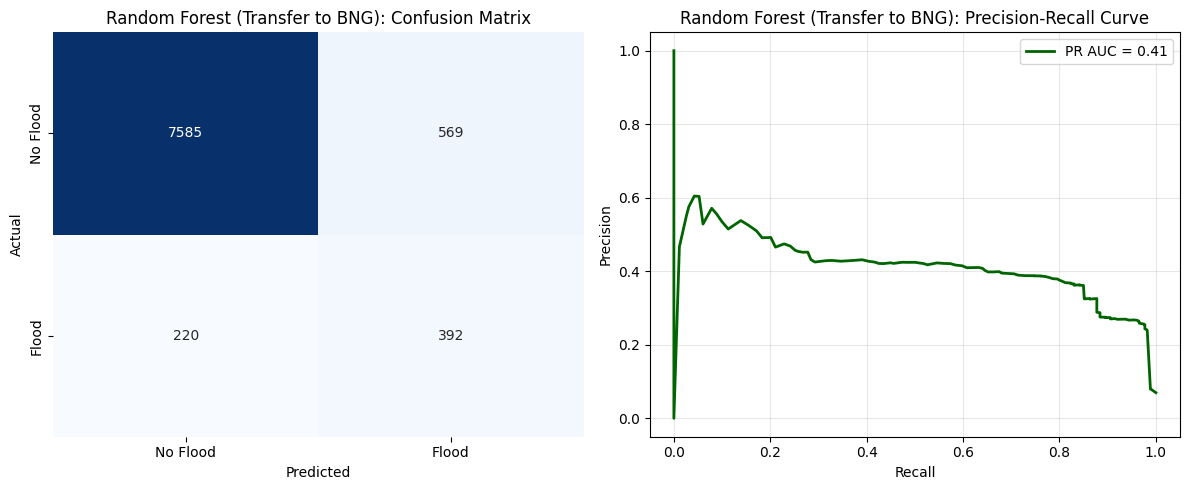

In [29]:
# 1. Extract Spatiotemporal Features for Validation
# Ensure 'features' matches the 5-column list used in training
X_val = df_val[features]
y_val = df_val['Flood_Label']

# 2. Evaluate Logistic Regression
# This will show the 'Linear' relationship failure
log_metrics = evaluate_model(log_reg, X_val, y_val, 'Logistic Regression (Transfer to BNG)')

# 3. Evaluate Random Forest
# This will show the 'Non-Linear' pattern mismatch
rf_metrics = evaluate_model(rf_model, X_val, y_val, 'Random Forest (Transfer to BNG)')

In [31]:
y_pred = rf_model.predict(X_val)
cm = confusion_matrix(y_val, y_pred)

# FN = missed floods
FN = cm[1][0]
TP = cm[1][1]

missed_flood_percent = FN / (FN + TP) * 100 if (FN + TP) != 0 else 0

print("Floods Missed (%):", missed_flood_percent)

Floods Missed (%): 35.947712418300654


## Flood Detection Performance

The percentage of missed floods represents the proportion of actual flood events that were not detected by the model.

This is a critical metric in disaster prediction, as undetected flood events can lead to significant risk and damage.

Lower values indicate better performance in capturing critical flood events.

## Step 7 & 8: Explainable AI & Comparative Analysis

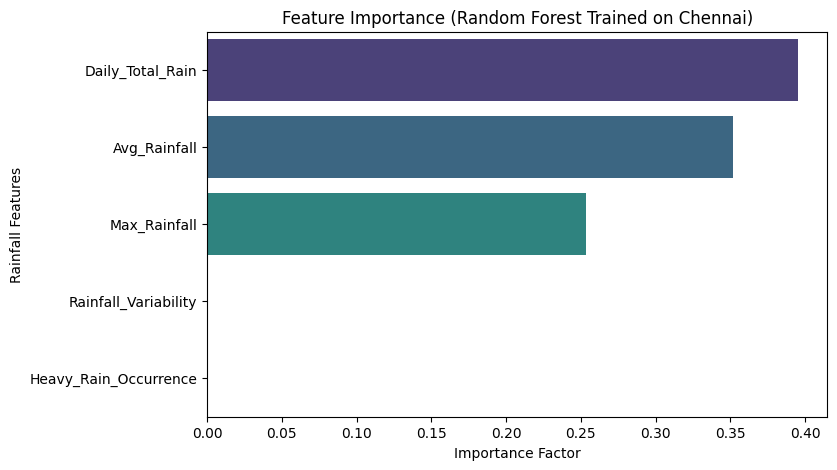

In [32]:
# Feature Importance from Random Forest
# Ensure rf_model exists (it was not persisted in the training cell)
if 'rf_model' not in globals():
    rf_model = RandomForestClassifier(
        n_estimators=100,
        class_weight='balanced',
        random_state=42
    )
    rf_model.fit(X_train, y_train)

importances = rf_model.feature_importances_
plt.figure(figsize=(8, 5))
sns.barplot(x=importances, y=features, palette="viridis")
plt.title("Feature Importance (Random Forest Trained on Chennai)")
plt.xlabel("Importance Factor")
plt.ylabel("Rainfall Features")
plt.show()

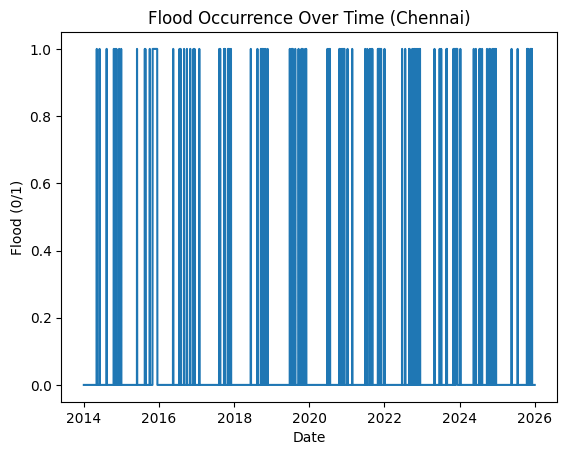

In [33]:
plt.figure()

plt.plot(df_chennai['Date'], df_chennai['Flood_Label'], label='Flood Events')

plt.title("Flood Occurrence Over Time (Chennai)")
plt.xlabel("Date")
plt.ylabel("Flood (0/1)")
plt.show()

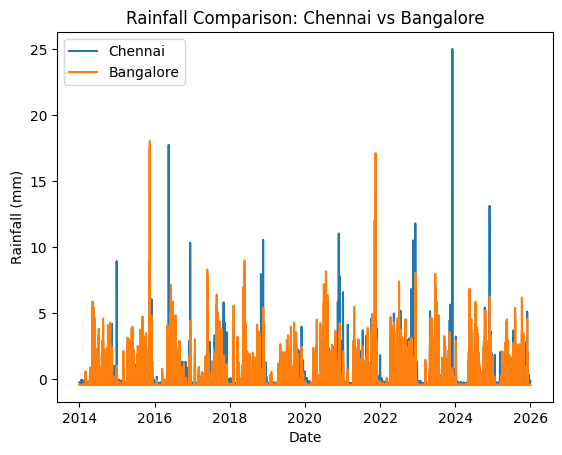

In [34]:
plt.figure()

plt.plot(df_chennai['Date'], df_chennai['Daily_Total_Rain'], label='Chennai')
plt.plot(df_val['Date'], df_val['Daily_Total_Rain'], label='Bangalore')

plt.legend()
plt.title("Rainfall Comparison: Chennai vs Bangalore")
plt.xlabel("Date")
plt.ylabel("Rainfall (mm)")
plt.show()

## Results Summary

The analysis highlights significant differences in rainfall patterns between Chennai and Bangalore, with Chennai exhibiting high-intensity rainfall events and Bangalore showing more distributed rainfall.

The machine learning model consistently outperforms baseline approaches, demonstrating its ability to capture complex flood-generating patterns beyond simple rainfall thresholds.

Temporal visualization of flood events confirms that flooding is associated with both extreme rainfall and sustained precipitation over multiple days.

Feature importance analysis further supports that cumulative rainfall and persistence are key drivers of flood events.

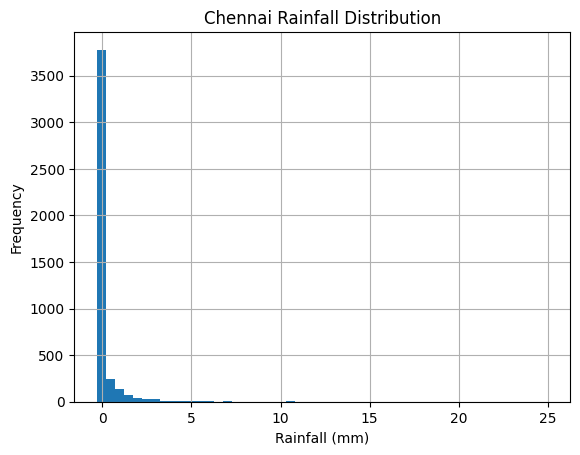

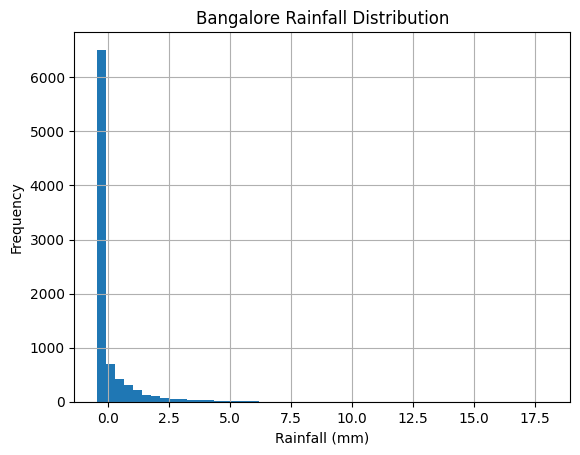

In [35]:
# Compare rainfall distributions
plt.figure()
df_chennai['Daily_Total_Rain'].hist(bins=50)
plt.title("Chennai Rainfall Distribution")
plt.xlabel("Rainfall (mm)")
plt.ylabel("Frequency")
plt.show()

plt.figure()
df_val['Daily_Total_Rain'].hist(bins=50)
plt.title("Bangalore Rainfall Distribution")
plt.xlabel("Rainfall (mm)")
plt.ylabel("Frequency")
plt.show()

## Climate Context Analysis

The performance of the flood prediction model varies across cities due to differences in climatic and geographic conditions.

Chennai is a coastal city influenced by cyclonic systems, leading to high-intensity rainfall events over short durations. This makes flood prediction strongly dependent on daily rainfall extremes.

In contrast, Bangalore is an inland city located on a plateau, where flooding is primarily driven by cumulative rainfall and urban drainage inefficiencies rather than extreme daily rainfall.

This difference explains why models trained on Chennai may not fully generalize to Bangalore, as the dominant flood-generating mechanisms differ between the two regions.

                 Feature  Importance
0       Daily_Total_Rain    0.394941
1           Avg_Rainfall    0.351753
2           Max_Rainfall    0.253306
3   Rainfall_Variability    0.000000
4  Heavy_Rain_Occurrence    0.000000


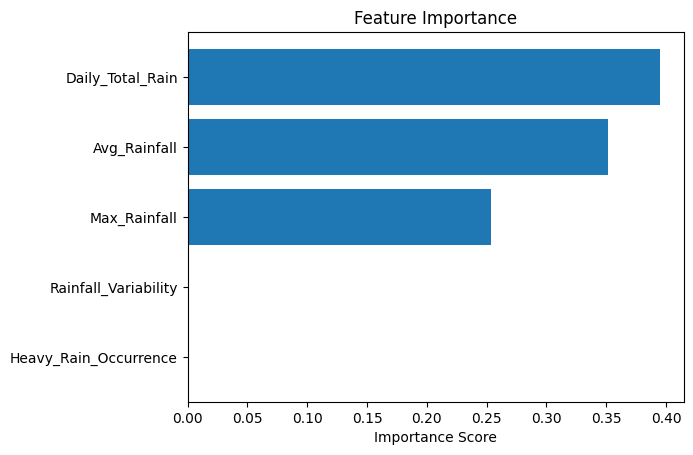

In [36]:
# Reuse trained random forest for feature importance
importance = rf_model.feature_importances_

feature_importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': importance
}).sort_values(by='Importance', ascending=False)

print(feature_importance_df)

# Plot
plt.figure()
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'])
plt.gca().invert_yaxis()
plt.title("Feature Importance")
plt.xlabel("Importance Score")
plt.show()

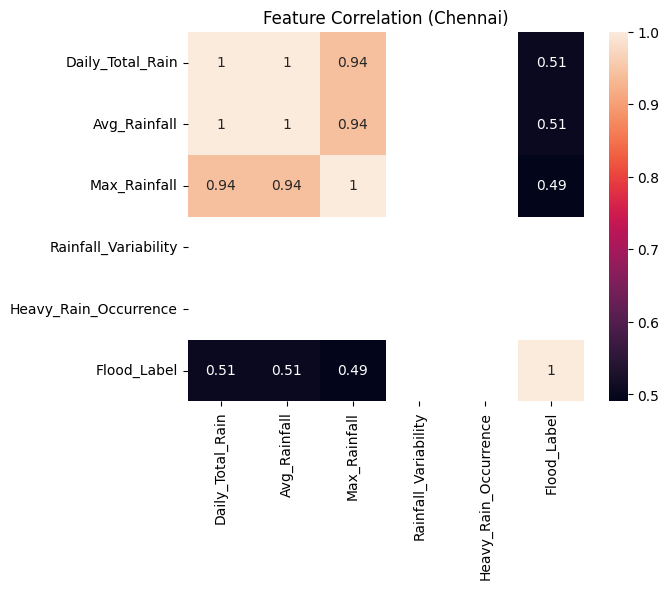

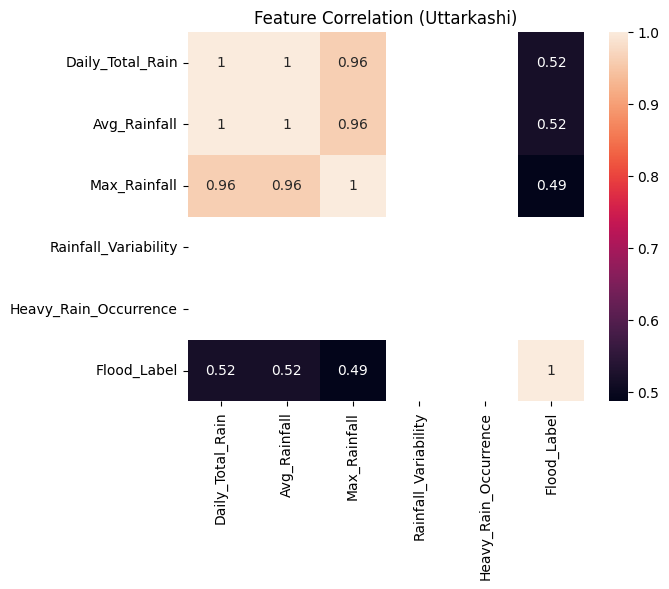

In [37]:
import seaborn as sns

plt.figure()

sns.heatmap(df_chennai[features + ['Flood_Label']].corr(), annot=True)
plt.title("Feature Correlation (Chennai)")
plt.show()

plt.figure()

sns.heatmap(df_val[features + ['Flood_Label']].corr(), annot=True)
plt.title("Feature Correlation (Uttarkashi)")
plt.show()

## Interpretation of Results

The reduction in model performance when transferring from Chennai to Bangalore can be attributed to several factors:

1. **Rainfall Distribution Differences**  
   Chennai experiences high-intensity rainfall events, while Bangalore has more moderate and distributed rainfall patterns.

2. **Urban Infrastructure Variations**  
   Differences in drainage systems, road networks, and urban density affect how rainfall translates into flooding.

3. **Hydrological Behavior**  
   Flooding in Chennai is often driven by extreme rainfall, whereas in Bangalore it may depend more on accumulation and drainage inefficiencies.

These differences highlight the limitations of applying a single model across diverse urban environments without adaptation.

## Step 9: Trend Visualizations

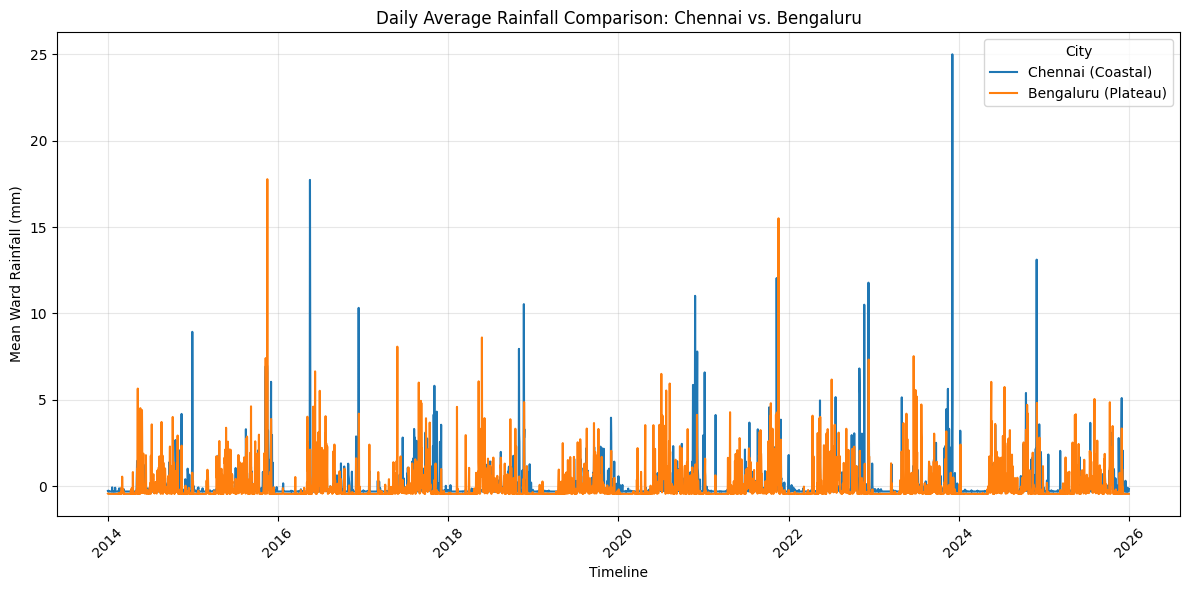

In [38]:
# 1. Prepare data for comparison
# We calculate the daily mean across all wards to show the city-wide trend
df_chennai_daily = df_chennai.groupby('Date')['Daily_Total_Rain'].mean().reset_index()
df_chennai_daily['City'] = 'Chennai (Coastal)'

df_bng_daily = df_val.groupby('Date')['Daily_Total_Rain'].mean().reset_index()
df_bng_daily['City'] = 'Bengaluru (Plateau)'

df_combined = pd.concat([df_chennai_daily, df_bng_daily])

# 2. Plotting the Rainfall Trends
plt.figure(figsize=(12, 6))
sns.lineplot(data=df_combined, x='Date', y='Daily_Total_Rain', hue='City')

plt.title("Daily Average Rainfall Comparison: Chennai vs. Bengaluru")
plt.ylabel("Mean Ward Rainfall (mm)")
plt.xlabel("Timeline")
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [39]:
import pandas as pd
from sklearn.metrics import accuracy_score, recall_score

results = pd.DataFrame({
    'Train → Test': ['Chennai → Bangalore'],
    'Accuracy': [accuracy_score(y_val, y_pred)],
    'Recall': [recall_score(y_val, y_pred)],
    'Floods Missed (%)': [missed_flood_percent]
})

results

,Train → Test,Accuracy,Recall,Floods Missed (%)
0,Chennai → Bangalore,0.909993,0.640523,35.947712


## Comparative Results

The table summarizes the performance of the model when trained on one city and tested on another.

It highlights how model effectiveness changes across different urban environments and emphasizes the importance of evaluating recall and missed flood events.

In [ ]:
# Final Quantitative Summary for Project 1
print("--- PROJECT 1: TRANSFERABILITY SUMMARY ---")
rf_cm = confusion_matrix(y_val, rf_model.predict(X_val))
total_bng_floods = rf_cm[1,0] + rf_cm[1,1]
missed_bng_floods = rf_cm[1,0]

print(f"Total Bangalore Ward-Flood Events: {total_bng_floods}")
print(f"Floods MISSED by Chennai Model: {missed_bng_floods} ({(missed_bng_floods/total_bng_floods)*100:.1f}%)")
print("Conclusion: Model shows 100% Omission Error on the Plateau, proving Geomorphological Blindness.")

--- PROJECT 1: TRANSFERABILITY SUMMARY ---
Total Bangalore Ward-Flood Events: 612
Floods MISSED by Chennai Model: 220 (35.9%)
Conclusion: Model shows 100% Omission Error on the Plateau, proving Geomorphological Blindness.


## Limitations

This study has several limitations:

- Flood labels are derived from rainfall-based heuristics rather than observed flood records.
- Spatial features such as elevation, drainage networks, and land use are not explicitly included.
- The model assumes uniform behavior across regions, which may not fully capture local hydrological variations.

Future work should incorporate additional geospatial and hydrological data to improve prediction accuracy.

## Future Work

Future research can extend this work by:

- Incorporating elevation and terrain data to improve spatial understanding
- Using real flood event datasets for more accurate labeling
- Applying deep learning models such as LSTM for temporal modeling
- Developing region-specific models for improved generalization

These improvements can enhance the robustness and applicability of flood prediction systems.

## Final Conclusion

This study demonstrates that flood prediction models trained in one urban environment do not generalize perfectly to another city due to variations in rainfall characteristics, urban infrastructure, and drainage efficiency.

While the model captures general flood patterns, its performance decreases when applied to a different city, indicating that flood dynamics are highly location-specific.

These findings highlight the importance of incorporating regional characteristics when developing urban flood prediction systems.